# NYC Building Energy & Water Benchmarking Analysis
## Springboard Capstone Two
### By Lauren Berg

**Dataset:** NYC Building Energy & Water Data Disclosure for Local Law 84, 2023 to Present  

## Research Question and Analysis Plan

**Central question:**  
What factors help explain differences in building energy and water performance, and how can peer-relative performance be used to identify buildings that may warrant further efficiency investigation or intervention?

**Issues and Questions to Explore:**
- How does Site EUI vary across property types?
- How do building size, building age, and energy-source composition relate to EUI?
- What distinguishes buildings that perform unusually well or poorly relative to buildings of the same property type?
- How does WUI vary across property types?
- Do building age and size relate to WUI in the same way they relate to EUI?
- Do buildings that perform well on energy also tend to perform well on water?

## Methodology Notes
- **Energy Source Composition:** Percent Electricity was used as the primary fuel-mix indicator because it provides a normalized measure that can be compared across buildings of different sizes and relatively complete coverage. Fuel Oil #2 and District Steam were excluded from broad comparison because more than 80% of records were missing. Natural gas field has better coverage, but represents absolute energy rather than a standardized share. 
- **Analysis Year:** The analysis was limited to 2024, the most recent and largest reporting year in the dataset, to provide a consistent cross-sectional comparison of current building performance. A future longitudinal analysis could track consistently reported properties across years to evaluate changes in EUI and WUI over time. 
- **Building Scope:** Only existing buildings with whole-property metering are used for the primary energy and water analyses.
- **Energy Metric:** Site EUI is retained as the main energy metric. Weather Normalized Site EUI is used as a sensitivity check to confirm that relative performance patterns were not materially different.
- **Summary Statistics:** Medians are emphasized for EUI and WUI because both distributions are skewed right, and contain extreme values that can disproportionaly influence the mean.

## 1. Import Libraries and Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import NYC Building Energy and Water dataset
csv_file = 'NYC_Building_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2023_to_Present_(Data_for_Calendar_Year_2022-Present)_20260901.csv'
df = pd.read_csv(csv_file, low_memory=False)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (103259, 265)


,Calendar Year,Property ID,Property Name,Parent Property ID,Parent Property Name,Year Ending,"NYC Borough, Block and Lot (BBL)",NYC Building Identification Number (BIN),Address 1,City,...,Aggregate Meter(s)-District Steam – Number of Individual Meters Included,Report Generation Date,Report Submission Date,Borough,Latitude,Longitude,Community Board,Council District,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020)
0,2022,6414946,58-01 Grand Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4026780001,4059918,58-01 Grand Avenue,Queens,...,NaN,04/25/2023 11:01:00 AM,04/25/2023 11:02:00 AM,QUEENS,40.719667,-73.911197,405.0,30.0,531.0,QN0501
1,2022,9793770,1870 Pelham Parkway South,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,2042500026,2047795,1870 Pelham Parkway South,Bronx,...,NaN,03/11/2023 02:00:00 PM,03/11/2023 02:01:00 PM,BRONX,40.855488,-73.830726,210.0,13.0,300.0,BX1003
2,2022,10177418,Central Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4157040040,4300145,2011 Mott Ave,Far Rockaway,...,NaN,04/14/2023 03:47:00 PM,04/14/2023 03:47:00 PM,QUEENS,40.604320,-73.753009,414.0,31.0,100803.0,QN1401
3,2022,13511507,215 East 99th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,1016490009,1052383,215 East 99th Street,New York,...,NaN,03/12/2023 03:54:00 PM,03/12/2023 03:54:00 PM,MANHATTAN,40.786963,-73.947537,111.0,8.0,164.0,MN1101
4,2022,14009907,23-25 31 Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4008350027,4017180,23-25 31 Street,Queens,...,NaN,04/28/2023 02:22:00 PM,04/28/2023 02:23:00 PM,QUEENS,40.773768,-73.913573,401.0,22.0,115.0,QN0101


In [2]:
# Inspect the dataset structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103259 entries, 0 to 103258
Columns: 265 entries, Calendar Year to Neighborhood Tabulation Area (NTA) (2020)
dtypes: bool(1), float64(8), int64(8), str(248)
memory usage: 208.1 MB


In [3]:
# Determine how much data is available for each calendar year
df['Calendar Year'].value_counts().sort_index()

Calendar Year
2022    30485
2023    33684
2024    39090
Name: count, dtype: int64

In [4]:
# Inspect "Not Available" values in energy-use columns
df[[column for column in df.columns if 'Use' in column and '(kBtu)' in column]].apply(
    lambda column: (column == 'Not Available').mean() * 100
).sort_values(ascending=False)

Kerosene Use (kBtu)                                                                   100.000000
Propane Use (kBtu)                                                                     99.999032
District Hot Water Use (kBtu)                                                          99.987410
Fuel Oil #1 Use (kBtu)                                                                 99.983537
Fuel Oil #5 & 6 Use (kBtu)                                                             99.973852
District Chilled Water Use (kBtu)                                                      99.927367
Diesel #2 Use (kBtu)                                                                   99.528370
Electricity Use – Generated from Onsite Renewable Systems and Used Onsite (kBtu)       99.417000
Fuel Oil #4 Use (kBtu)                                                                 96.300565
District Steam Use (kBtu)                                                              95.820219
Fuel Oil #2 Use (kBtu)        

## 2. Data Cleaning

The analysis uses 2024 records only, as we are comparing building performance by property type and building characteristic, rather than looking at performance over time. This analysis keeps a focused set of variables, and restricts the dataset to existing buildings (removes 'planned' or 'test' buildings), and those with wholistic energy reporting rather than those with only partial property reporting. Energy and water analyses are separated because usable metering coverage differs between the two.

In [5]:
# Copy the original dataframe so the source data remains unchanged
df_clean = df.copy()

# Keep only 2024 data
df_clean = df_clean[df_clean['Calendar Year'] == 2024]

# Keep only columns needed for this analysis
columns_to_keep = [
    'Calendar Year',
    'Property ID',
    'Borough',
    'Longitude',
    'Latitude',
    'Primary Property Type - Portfolio Manager-Calculated',
    'Year Built',
    'Number of Buildings',
    'Occupancy',
    'Property GFA - Self-Reported (ft²)',
    'NYC Building Identification Number (BIN)',
    'Metered Areas (Energy)',
    'Metered Areas (Water)',
    'Construction Status',
    'Site EUI (kBtu/ft²)',
    'Weather Normalized Site EUI (kBtu/ft²)',
    'Percent Electricity',
    'Natural Gas Use (kBtu)',
    'Electricity Use - Grid Purchase (kBtu)',
    'Fuel Oil #2 Use (kBtu)',
    'District Steam Use (kBtu)',
    'Water Use (All Water Sources) (kgal)'
]

df_clean2 = df_clean[columns_to_keep].copy()

# Keep only existing buildings; exclude test/design records
df_clean3 = df_clean2[df_clean2['Construction Status'] == 'Existing'].copy()

print('Shape after year, column, and construction-status filters:', df_clean3.shape)

Shape after year, column, and construction-status filters: (38857, 22)


In [6]:
# Inspect how many "Not Available" entries remain
percent_not_available = (df_clean3 == 'Not Available').mean() * 100
percent_not_available[percent_not_available > 0].sort_values(ascending=False)

District Steam Use (kBtu)                               96.229766
Fuel Oil #2 Use (kBtu)                                  87.595543
Water Use (All Water Sources) (kgal)                    52.103868
Metered Areas (Water)                                   36.482487
Natural Gas Use (kBtu)                                  25.779139
Weather Normalized Site EUI (kBtu/ft²)                  24.628767
Percent Electricity                                     23.733175
Electricity Use - Grid Purchase (kBtu)                  22.454127
Site EUI (kBtu/ft²)                                     21.432432
Metered Areas (Energy)                                  18.833157
NYC Building Identification Number (BIN)                 0.844121
Primary Property Type - Portfolio Manager-Calculated     0.110662
dtype: float64

In [7]:
# Inspect whole-property metering coverage
print('Energy metering:')
print(df_clean3['Metered Areas (Energy)'].value_counts(dropna=False))

print('\nWater metering:')
print(df_clean3['Metered Areas (Water)'].value_counts(dropna=False))

Energy metering:
Metered Areas (Energy)
Whole Property                                                                                                                                                                        30711
Not Available                                                                                                                                                                          7318
NaN                                                                                                                                                                                     539
Another configuration                                                                                                                                                                   264
Common areas (all energy or water loads)                                                                                                                                                  9
Tenant areas (all en

In [8]:
# Remove commas from Property GFA so it can be converted to a number
df_clean3['Property GFA - Self-Reported (ft²)'] = (
    df_clean3['Property GFA - Self-Reported (ft²)']
    .str.replace(',', '', regex=False)
)

# Identify numeric columns that need conversion
numeric_columns = [
    'Property GFA - Self-Reported (ft²)',
    'Site EUI (kBtu/ft²)',
    'Weather Normalized Site EUI (kBtu/ft²)',
    'Percent Electricity',
    'Natural Gas Use (kBtu)',
    'Electricity Use - Grid Purchase (kBtu)',
    'Fuel Oil #2 Use (kBtu)',
    'District Steam Use (kBtu)',
    'Water Use (All Water Sources) (kgal)'
]

# Convert numeric columns so "Not Available" becomes NaN
for column in numeric_columns:
    df_clean3[column] = pd.to_numeric(df_clean3[column], errors='coerce')

In [9]:
# Inspect ranges for the main energy-analysis variables
df_clean3[[
    'Site EUI (kBtu/ft²)',
    'Property GFA - Self-Reported (ft²)',
    'Year Built',
    'Occupancy',
    'Number of Buildings'
]].describe()

,Site EUI (kBtu/ft²),Property GFA - Self-Reported (ft²),Year Built,Occupancy,Number of Buildings
count,3.052900e+04,3.885700e+04,38857.000000,38857.000000,38857.000000
mean,5.078365e+03,1.082365e+05,1952.622179,96.980724,1.415987
std,1.469173e+05,2.745076e+05,34.167654,11.893705,5.687585
min,0.000000e+00,0.000000e+00,1367.000000,0.000000,0.000000
25%,4.940000e+01,3.035000e+04,1927.000000,100.000000,1.000000
50%,6.950000e+01,5.327400e+04,1950.000000,100.000000,1.000000
75%,9.090000e+01,1.036620e+05,1972.000000,100.000000,1.000000
max,1.128538e+07,2.115016e+07,2088.000000,100.000000,514.000000


In [10]:
# Check potentially invalid or unusual values
print('EUI = 0:')
print((df_clean3['Site EUI (kBtu/ft²)'] == 0).sum())

print('\nGFA <= 0:')
print((df_clean3['Property GFA - Self-Reported (ft²)'] <= 0).sum())

print('\nGFA < 1,000 sqft:')
print((df_clean3['Property GFA - Self-Reported (ft²)'] < 1000).sum())

print('\nYear Built after 2024:')
print((df_clean3['Year Built'] > 2024).sum())

print('\nYear Built before 1800:')
print((df_clean3['Year Built'] < 1800).sum())

print('\nNumber of Buildings = 0:')
print((df_clean3['Number of Buildings'] == 0).sum())

print('\nOccupancy = 0:')
print((df_clean3['Occupancy'] == 0).sum())

EUI = 0:
75

GFA <= 0:
9

GFA < 1,000 sqft:
583

Year Built after 2024:
7

Year Built before 1800:
6

Number of Buildings = 0:
1118

Occupancy = 0:
304


In [11]:
# Inspect zero-occupancy records before deciding whether to remove them
df_clean3[df_clean3['Occupancy'] == 0][[
    'Property ID',
    'Borough',
    'Primary Property Type - Portfolio Manager-Calculated',
    'Property GFA - Self-Reported (ft²)',
    'Site EUI (kBtu/ft²)',
    'Number of Buildings'
]]

,Property ID,Borough,Primary Property Type - Portfolio Manager-Calculated,Property GFA - Self-Reported (ft²),Site EUI (kBtu/ft²),Number of Buildings
64234,1345438,MANHATTAN,Office,1339997,47.3,1
64251,1426638,MANHATTAN,Office,375225,12.5,1
66482,2675437,BROOKLYN,Office,93733,29.0,1
66847,2708994,BROOKLYN,Retail Store,919187,30.7,1
69500,3244504,MANHATTAN,Hotel,92501,0.3,1
...,...,...,...,...,...,...
103121,65664293,BROOKLYN,Multifamily Housing,112091,81.0,2
103238,66084381,NaN,Multifamily Housing,47745,NaN,1
103239,66087807,NaN,Multifamily Housing,47745,NaN,1
103240,66087808,NaN,Multifamily Housing,47745,NaN,1


In [12]:
# Inspect records with Year Built before 1800
# Two records (1367 and 1600) were identified as implausible reporting errors;
# legitimate historic buildings from the 1700s are retained.
df_clean3[df_clean3['Year Built'] < 1800][[
    'Property ID',
    'NYC Building Identification Number (BIN)',
    'Borough',
    'Primary Property Type - Portfolio Manager-Calculated',
    'Year Built',
    'Property GFA - Self-Reported (ft²)',
    'Site EUI (kBtu/ft²)'
]]

,Property ID,NYC Building Identification Number (BIN),Borough,Primary Property Type - Portfolio Manager-Calculated,Year Built,Property GFA - Self-Reported (ft²),Site EUI (kBtu/ft²)
66609,2682163,1001087,MANHATTAN,Office,1600,276000,43.7
83670,16734560,3070556,BROOKLYN,Non-Refrigerated Warehouse,1367,85000,78.6
85468,21353692,2114843; 2123971; 2123972; 2000000; 2123986; 2...,NaN,Other - Recreation,1749,37849,62.3
85469,21353693,2114843,NaN,Museum,1749,11961,44.7
86207,21354482,3337842;3347228;3029666;3398161;3856674,BROOKLYN,Other - Entertainment/Public Assembly,1783,153794,177.9
86215,21354490,3347228,NaN,Museum,1783,3185,26.1


In [13]:
# Inspect very low and very high EUI values
print('EUI < 5:')
print((df_clean3['Site EUI (kBtu/ft²)'] < 5).sum())

print('\nEUI > 1000:')
print((df_clean3['Site EUI (kBtu/ft²)'] > 1000).sum())

# View the largest EUI records
df_clean3.nlargest(10, 'Site EUI (kBtu/ft²)')[[
    'Property ID',
    'Primary Property Type - Portfolio Manager-Calculated',
    'Site EUI (kBtu/ft²)',
    'Property GFA - Self-Reported (ft²)'
]]

EUI < 5:
470

EUI > 1000:
143


,Property ID,Primary Property Type - Portfolio Manager-Calculated,Site EUI (kBtu/ft²),Property GFA - Self-Reported (ft²)
81404,10856048,Multifamily Housing,11285380.0,1
90380,33594144,Multifamily Housing,7782928.0,1
90381,33594146,Multifamily Housing,7385251.0,1
90382,33594148,Multifamily Housing,7110620.0,1
90378,33594028,Multifamily Housing,6691124.0,1
90035,33158452,Multifamily Housing,5254486.0,1
90423,33617032,Multifamily Housing,4958371.0,1
90420,33617005,Multifamily Housing,4546872.0,1
81461,10877213,Multifamily Housing,4322905.0,1
90416,33616915,Multifamily Housing,4175622.0,1


In [14]:
# Apply basic structural data quality filters
# NOTE: Year Built == 2024 is retained; only future years are removed.
df_clean3 = df_clean3[df_clean3['Property GFA - Self-Reported (ft²)'] > 1].copy()
df_clean3 = df_clean3[df_clean3['Year Built'] <= 2024].copy()
df_clean3 = df_clean3[df_clean3['Number of Buildings'] > 0].copy()
df_clean3 = df_clean3[df_clean3['Occupancy'] > 0].copy()

# Remove two implausible Year Built records identified during inspection
df_clean3 = df_clean3[~df_clean3['Year Built'].isin([1367, 1600])].copy()

print('Dataframe shape after basic quality filters:', df_clean3.shape)
print('EUI < 5:', (df_clean3['Site EUI (kBtu/ft²)'] < 5).sum())
print('EUI > 1000:', (df_clean3['Site EUI (kBtu/ft²)'] > 1000).sum())

Dataframe shape after basic quality filters: (37227, 22)
EUI < 5: 409
EUI > 1000: 80


In [15]:
# Create separate analysis dataframes for energy and water use, using only whole-property metering
df_energy = df_clean3[df_clean3['Metered Areas (Energy)'] == 'Whole Property'].copy()
df_water = df_clean3[df_clean3['Metered Areas (Water)'] == 'Whole Property'].copy()

print('Energy subset:', df_energy.shape)
print('Water subset:', df_water.shape)

Energy subset: (30373, 22)
Water subset: (22920, 22)


In [16]:
# Inspect remaining missing values in each analysis dataframe
energy_missing = df_energy.isna().mean() * 100
water_missing = df_water.isna().mean() * 100

print('Energy missing values (%):')
print(energy_missing[energy_missing > 0].sort_values(ascending=False))

print('\nWater missing values (%):')
print(water_missing[water_missing > 0].sort_values(ascending=False))

Energy missing values (%):
District Steam Use (kBtu)                 95.321503
Fuel Oil #2 Use (kBtu)                    84.265631
Water Use (All Water Sources) (kgal)      39.976295
Natural Gas Use (kBtu)                     7.987357
Weather Normalized Site EUI (kBtu/ft²)     7.174135
Percent Electricity                        5.491720
Metered Areas (Water)                      4.563263
Electricity Use - Grid Purchase (kBtu)     3.937708
Longitude                                  3.345076
Latitude                                   3.345076
Borough                                    3.331907
Site EUI (kBtu/ft²)                        3.160702
dtype: float64

Water missing values (%):
District Steam Use (kBtu)                 94.825480
Fuel Oil #2 Use (kBtu)                    84.995637
Water Use (All Water Sources) (kgal)      25.488656
Weather Normalized Site EUI (kBtu/ft²)     7.473822
Natural Gas Use (kBtu)                     7.094241
Percent Electricity                        3.83

In [17]:
# Remove rows without the primary outcome needed for each analysis
df_energy = df_energy.dropna(subset=['Site EUI (kBtu/ft²)']).copy()
df_water = df_water.dropna(subset=['Water Use (All Water Sources) (kgal)']).copy()

print('Energy shape after dropping missing Site EUI:', df_energy.shape)
print('Water shape after dropping missing water use:', df_water.shape)

Energy shape after dropping missing Site EUI: (29413, 22)
Water shape after dropping missing water use: (17078, 22)


In [18]:
# Check for duplicate property IDs
print('Energy duplicate Property IDs:', df_energy['Property ID'].duplicated().sum())
print('Water duplicate Property IDs:', df_water['Property ID'].duplicated().sum())

Energy duplicate Property IDs: 0
Water duplicate Property IDs: 0


### 2.1 Energy and Water Data Quality Checks

In [19]:
# Inspect EUI upper-tail percentiles and extreme counts
print(df_energy['Site EUI (kBtu/ft²)'].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
))

print('\nEUI > 1,000:', (df_energy['Site EUI (kBtu/ft²)'] > 1000).sum())
print('EUI > 5,000:', (df_energy['Site EUI (kBtu/ft²)'] > 5000).sum())
print('EUI > 10,000:', (df_energy['Site EUI (kBtu/ft²)'] > 10000).sum())

0.500        69.800
0.750        90.700
0.900       121.000
0.950       155.940
0.990       344.992
0.995       591.770
1.000    752242.700
Name: Site EUI (kBtu/ft²), dtype: float64

EUI > 1,000: 75
EUI > 5,000: 25
EUI > 10,000: 18


In [20]:
# Remove unusually high EUI records that appear to be reporting anomalies
df_energy = df_energy[df_energy['Site EUI (kBtu/ft²)'] <= 1000].copy()

In [21]:
# Create a grouped property-type field for descriptive charts only
# Individual source categories with fewer than 10 buildings are combined.
property_counts = df_energy['Primary Property Type - Portfolio Manager-Calculated'].value_counts()
rare_property_types = property_counts[property_counts < 10].index

df_energy['Property Type Grouped'] = (
    df_energy['Primary Property Type - Portfolio Manager-Calculated']
    .replace(rare_property_types, 'Rare Property Types')
)

df_energy['Property Type Grouped'].value_counts()

Property Type Grouped
Multifamily Housing                           19704
Office                                         2233
K-12 School                                    1816
Hotel                                           644
Non-Refrigerated Warehouse                      391
Manufacturing/Industrial Plant                  348
Self-Storage Facility                           332
Mixed Use Property                              295
Retail Store                                    289
Worship Facility                                198
College/University                              189
Other - Recreation                              186
Senior Living Community                         174
Distribution Center                             171
Residence Hall/Dormitory                        156
Parking                                         148
Other - Lodging/Residential                     133
Pre-school/Daycare                              131
Vehicle Repair Services                   

In [22]:
# Look at water dataframe
df_water[[
    'Water Use (All Water Sources) (kgal)',
    'Property GFA - Self-Reported (ft²)',
    'Year Built',
    'Occupancy',
    'Number of Buildings'
]].describe()

,Water Use (All Water Sources) (kgal),Property GFA - Self-Reported (ft²),Year Built,Occupancy,Number of Buildings
count,1.707800e+04,1.707800e+04,17078.000000,17078.000000,17078.000000
mean,5.268130e+03,1.132157e+05,1951.698267,97.743881,1.315552
std,1.755366e+04,1.979480e+05,35.577989,8.320038,3.927287
min,0.000000e+00,1.000000e+01,1749.000000,5.000000,1.000000
25%,1.361525e+03,3.900000e+04,1926.000000,100.000000,1.000000
50%,3.019900e+03,6.002850e+04,1940.000000,100.000000,1.000000
75%,5.652050e+03,1.089858e+05,1975.000000,100.000000,1.000000
max,1.425133e+06,5.970773e+06,2024.000000,100.000000,179.000000


In [23]:
# Create a grouped property-type field for descriptive water charts
property_counts_water = df_water['Primary Property Type - Portfolio Manager-Calculated'].value_counts()
rare_property_types_water = property_counts_water[property_counts_water < 10].index

df_water['Property Type Grouped'] = (
    df_water['Primary Property Type - Portfolio Manager-Calculated']
    .replace(rare_property_types_water, 'Rare Property Types')
)

print('Water Use = 0:', (df_water['Water Use (All Water Sources) (kgal)'] == 0).sum())

Water Use = 0: 40


In [24]:
# Inspect zero-water-use records by property type
df_water[df_water['Water Use (All Water Sources) (kgal)'] == 0][[
    'Property ID',
    'Property Type Grouped',
    'Occupancy',
    'Property GFA - Self-Reported (ft²)',
    'Water Use (All Water Sources) (kgal)'
]]

,Property ID,Property Type Grouped,Occupancy,Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal)
65752,2646028,Hospital (General Medical & Surgical),100,186407,0.0
66201,2667012,Other - Specialty Hospital,100,140014,0.0
68543,2893900,Self-Storage Facility,100,111384,0.0
68544,2893901,Self-Storage Facility,100,85787,0.0
69748,3512131,Data Center,100,57656,0.0
70347,4034138,Medical Office,100,64093,0.0
71150,4404099,Office,100,94000,0.0
71848,4600601,Self-Storage Facility,100,307148,0.0
74928,6290934,Worship Facility,100,31500,0.0
76903,6664906,Multifamily Housing,100,27820,0.0


In [25]:
# Remove occupied whole-property records reporting zero water use
df_water = df_water[df_water['Water Use (All Water Sources) (kgal)'] > 0].copy()

In [26]:
# Create Building Age columns
df_energy['Building Age'] = 2024 - df_energy['Year Built']
df_water['Building Age'] = 2024 - df_water['Year Built']

# Create Water Use Intensity in gallons per square foot
# Source water use is reported in thousand gallons (kgal), so multiply by 1,000.
df_water['Water Use Intensity (WUI) (gal/ft²)'] = (
    df_water['Water Use (All Water Sources) (kgal)'] /
    df_water['Property GFA - Self-Reported (ft²)']
) * 1000

print('Energy building age:')
print(df_energy['Building Age'].describe())

print('\nWater building age:')
print(df_water['Building Age'].describe())

print('\nWUI:')
print(df_water['Water Use Intensity (WUI) (gal/ft²)'].describe())

Energy building age:
count    29338.000000
mean        71.739042
std         35.810869
min          0.000000
25%         48.000000
50%         83.000000
75%         98.000000
max        275.000000
Name: Building Age, dtype: float64

Water building age:
count    17038.000000
mean        72.351861
std         35.553727
min          0.000000
25%         49.000000
50%         85.000000
75%         98.000000
max        275.000000
Name: Building Age, dtype: float64

WUI:
count    17038.000000
mean        65.257656
std        510.137380
min          0.000893
25%         22.194705
50%         43.924637
75%         75.137216
max      56930.000000
Name: Water Use Intensity (WUI) (gal/ft²), dtype: float64


In [27]:
# Inspect the upper tail of WUI
df_water['Water Use Intensity (WUI) (gal/ft²)'].quantile(
    [0.90, 0.95, 0.99, 0.995, 1.00]
)

0.900      115.985021
0.950      146.639262
0.990      238.057967
0.995      306.013059
1.000    56930.000000
Name: Water Use Intensity (WUI) (gal/ft²), dtype: float64

In [28]:
# Investigate unusually small buildings and unusual water-use values
print('GFA < 1,000 sqft:')
print((df_water['Property GFA - Self-Reported (ft²)'] < 1000).sum())

print('\nWUI > 1,000 gal/ft²:')
print((df_water['Water Use Intensity (WUI) (gal/ft²)'] > 1000).sum())

print('\nWater use < 1 kgal:')
print((df_water['Water Use (All Water Sources) (kgal)'] < 1).sum())

GFA < 1,000 sqft:
2

WUI > 1,000 gal/ft²:
25

Water use < 1 kgal:
12


In [29]:
# Inspect buildings with GFA under 1,000 sqft
df_water[df_water['Property GFA - Self-Reported (ft²)'] < 1000][[
    'Property ID',
    'Property Type Grouped',
    'Number of Buildings',
    'Occupancy',
    'Property GFA - Self-Reported (ft²)',
    'Water Use (All Water Sources) (kgal)',
    'Water Use Intensity (WUI) (gal/ft²)'
]]

,Property ID,Property Type Grouped,Number of Buildings,Occupancy,Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Use Intensity (WUI) (gal/ft²)
87102,21355522,Other,1,100,600,32.2,53.666667
92588,47969694,Office,1,100,10,569.3,56930.000000


In [30]:
# Remove one property with an implausible 10 sqft reported GFA from both analyses
df_water = df_water[df_water['Property ID'] != 47969694].copy()
df_energy = df_energy[df_energy['Property ID'] != 47969694].copy()

# Remove implausibly low annual water-use records (< 1 kgal)
df_water = df_water[df_water['Water Use (All Water Sources) (kgal)'] >= 1].copy()

# Inspect WUI records above 1,000 gal/ft² before removing them
high_wui = df_water[
    df_water['Water Use Intensity (WUI) (gal/ft²)'] > 1000
].copy()

high_wui[[
    'Property ID',
    'Property Type Grouped',
    'Property GFA - Self-Reported (ft²)',
    'Water Use (All Water Sources) (kgal)',
    'Water Use Intensity (WUI) (gal/ft²)'
]].sort_values('Water Use Intensity (WUI) (gal/ft²)', ascending=False)

,Property ID,Property Type Grouped,Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Use Intensity (WUI) (gal/ft²)
97850,57808992,Office,11000,301943.5,27449.409091
81023,10423759,Multifamily Housing,28595,252122.1,8816.999475
81022,10423700,Multifamily Housing,25280,206329.2,8161.756329
75462,6322782,Multifamily Housing,27927,210018.2,7520.256383
82067,12069108,Multifamily Housing,5952,35285.6,5928.360215
81711,11609762,Multifamily Housing,86190,473008.6,5487.975403
82426,13793286,Multifamily Housing,44689,236861.7,5300.223769
68567,2916294,Multifamily Housing,69785,349024.5,5001.425808
82063,12069104,Multifamily Housing,5952,27230.6,4575.033602
103246,66101392,Office,32790,149430.8,4557.206465


In [31]:
# Remove extreme WUI values that appear to be reporting anomalies
df_water = df_water[
    df_water['Water Use Intensity (WUI) (gal/ft²)'] <= 1000
].copy()

df_water['Water Use Intensity (WUI) (gal/ft²)'].describe()

count    17001.000000
mean        55.713051
std         52.550660
min          0.003701
25%         22.197196
50%         43.870883
75%         74.962086
max        948.745364
Name: Water Use Intensity (WUI) (gal/ft²), dtype: float64

## 2.2 Function Creation

A reusable summary function was created to calculate property-type sample size and median resource intensity for both EUI and WUI analyses.

In [32]:
# Start the function
def summary_by_property_type(dataframe, column):
    summary = (

        # Group by property type
        dataframe.groupby( 'Property Type Grouped'

                           # Calculate count and median for the metric, sort by median
                         )[column].agg(['count', 'median']).sort_values('median', ascending=False)
    )

    # Return the summary table
    return summary

## 3. Energy Performance Analysis

The energy analysis begins with the overall EUI distribution, then examines property type, building size, building age, and percent electricity.

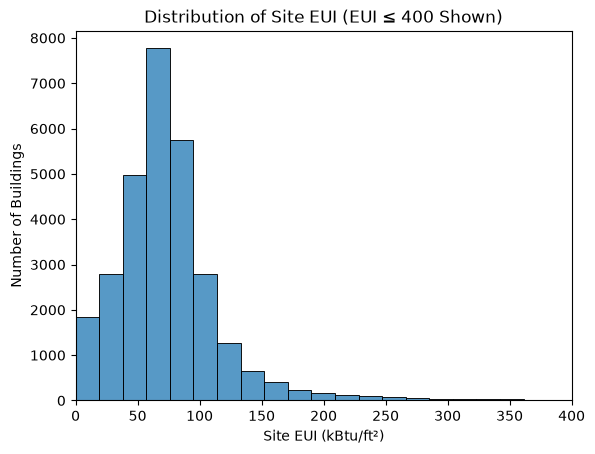

In [33]:
# Show the main body of the EUI distribution without deleting values above 400
sns.histplot(
    data=df_energy,
    x='Site EUI (kBtu/ft²)',
    bins=50
)

plt.title('Distribution of Site EUI (EUI ≤ 400 Shown)')
plt.xlabel('Site EUI (kBtu/ft²)')
plt.ylabel('Number of Buildings')
plt.xlim(0, 400)
plt.show()

### 3.1 EUI by Property Type

**Median EUI** is used because the distribution is **right-skewed**. Property type is expected to be a major source of variation because different building uses have very different equipment, ventilation, refrigeration, occupancy, and process-energy requirements.

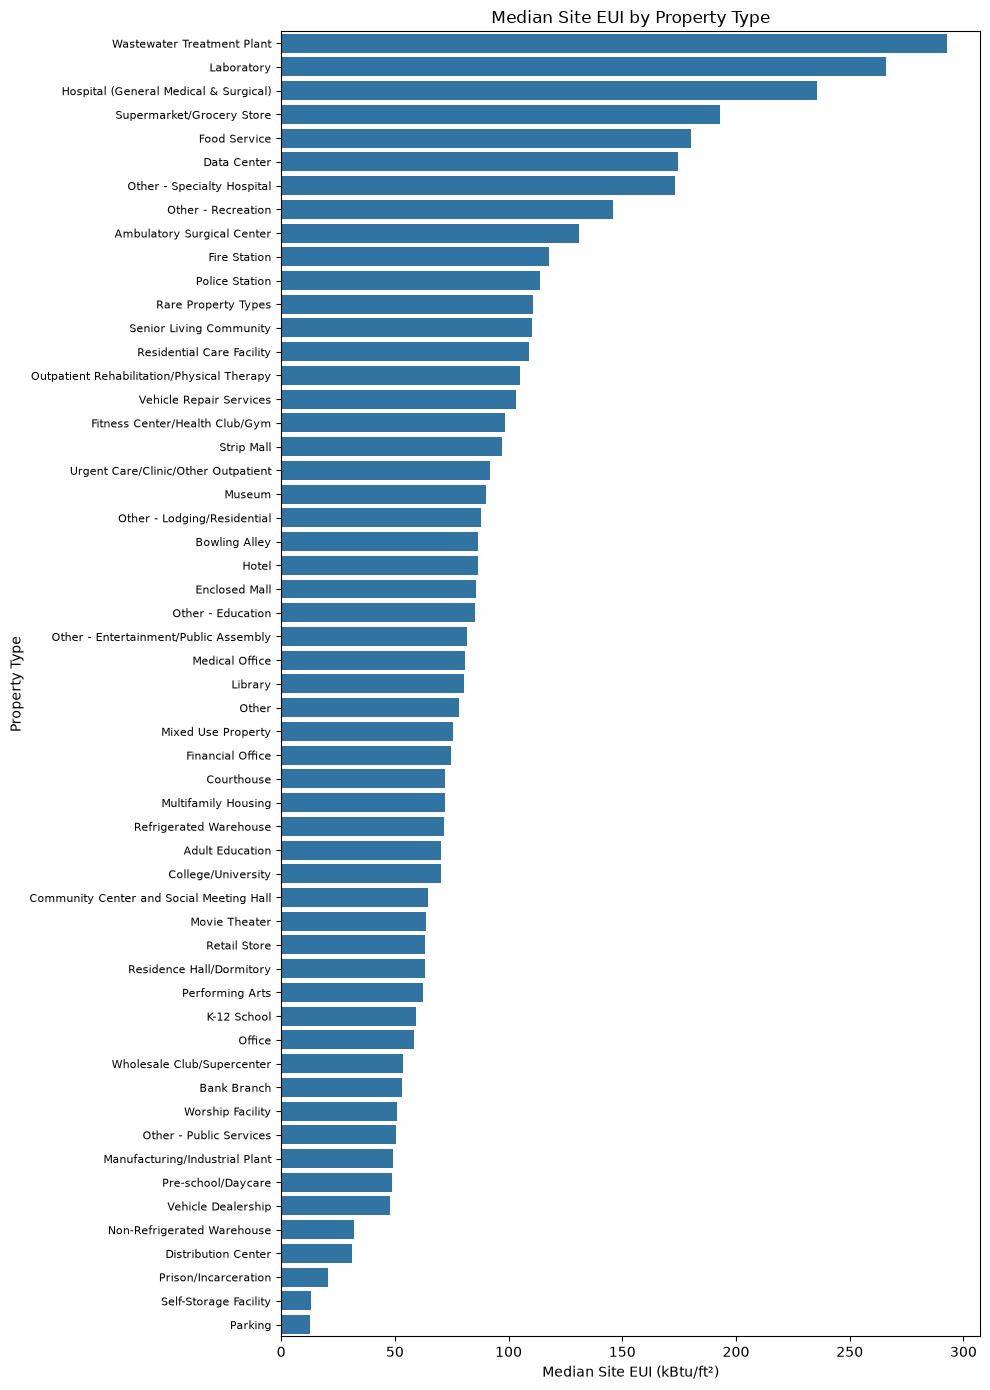

,count,median
Property Type Grouped,,
Wastewater Treatment Plant,14,292.65
Laboratory,30,265.80
Hospital (General Medical & Surgical),98,235.60
Supermarket/Grocery Store,99,193.10
Food Service,18,180.00
Data Center,64,174.50
Other - Specialty Hospital,19,173.00
Other - Recreation,186,145.80
Ambulatory Surgical Center,16,131.00


In [34]:
# Use summary_by_property_type function to create new variable
eui_property_summary = summary_by_property_type(
    df_energy,
    'Site EUI (kBtu/ft²)'
)

# Use the index to determine property order for our bar plot
property_order = eui_property_summary.index

# Create bar plot of Median Site EUI by Property Type
plt.figure(figsize=(10, 14))

sns.barplot(
    data=df_energy,
    y='Property Type Grouped',
    x='Site EUI (kBtu/ft²)',
    order=property_order,
    estimator=np.median,
    errorbar=None
)

plt.title('Median Site EUI by Property Type')
plt.xlabel('Median Site EUI (kBtu/ft²)')
plt.ylabel('Property Type')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Show sample size and median EUI for each grouped property type
eui_property_summary

### Insight: Property type is a major source of EUI variation

Median Site EUI differs substantially across property types. Among the larger, more stable categories, the highest medians include **Wastewater Treatment Plant (292.7 kBtu/ft²)**, **Laboratory (265.8 kBtu/ft²)**, **Hospital — General Medical & Surgical (235.6 kBtu/ft²)**, and **Supermarket/Grocery Store (193.1 kBtu/ft²)**. At the low end, **Parking (12.8 kBtu/ft²)** and **Self-Storage Facility (13.3 kBtu/ft²)** have much lower median EUI.

These results suggest that building use matters substantially when discussing energy performance. There is an operational pattern to be observed: laboratories, hospitals, supermarkets, and wastewater facilities have energy-intensive equipment, ventilation, refrigeration, or process loads, while parking and storage facilities typically have much lower conditioning and equipment needs.

Small categories should be interpreted cautiously. For example, Zoo has a very high median but only 7 observations after cleaning.

### 3.2 Building Size and EUI

The scatterplot, below, is displayed only to 1.5 million ft² so the main pattern is visible. This is a display choice, not an additional data filter.

In [35]:
# Inspect GFA percentiles
df_energy['Property GFA - Self-Reported (ft²)'].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
)

0.500       62159.00
0.750      115343.75
0.900      234692.20
0.950      397618.00
0.990     1072872.72
0.995     1452458.43
1.000    21150159.00
Name: Property GFA - Self-Reported (ft²), dtype: float64

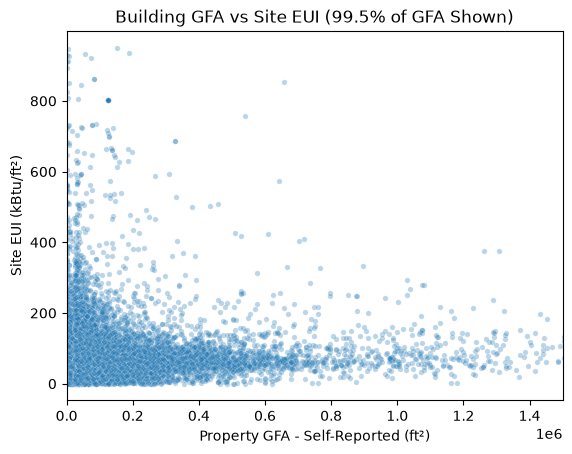

,Property GFA - Self-Reported (ft²),Site EUI (kBtu/ft²)
Property GFA - Self-Reported (ft²),1.000000,0.033772
Site EUI (kBtu/ft²),0.033772,1.000000


In [36]:
# Plot building size vs Site EUI
sns.scatterplot(
    x='Property GFA - Self-Reported (ft²)',
    y='Site EUI (kBtu/ft²)',
    data=df_energy,
    alpha=0.3,
    s=15
)

# Limit x-axis to display 99.5% of GFA values
plt.title('Building GFA vs Site EUI (99.5% of GFA Shown)')
plt.xlabel('Property GFA - Self-Reported (ft²)')
plt.ylabel('Site EUI (kBtu/ft²)')
plt.xlim(0, 1500000)
plt.show()

# Correlation between size and Site EUI
df_energy[[
    'Property GFA - Self-Reported (ft²)',
    'Site EUI (kBtu/ft²)'
]].corr()

### Insight: Building size has almost no overall linear relationship with EUI

The correlation between GFA and Site EUI is **0.034**, which is effectively no linear relationship in the full dataset. The scatterplot also shows wide variation in EUI among smaller buildings rather than a clear upward or downward pattern.

This suggests that **building size alone is not a useful explanation of EUI differences** across all property types. Any size effect may be more context-specific and could differ within individual building-use categories.


### 3.3 Building Age and EUI

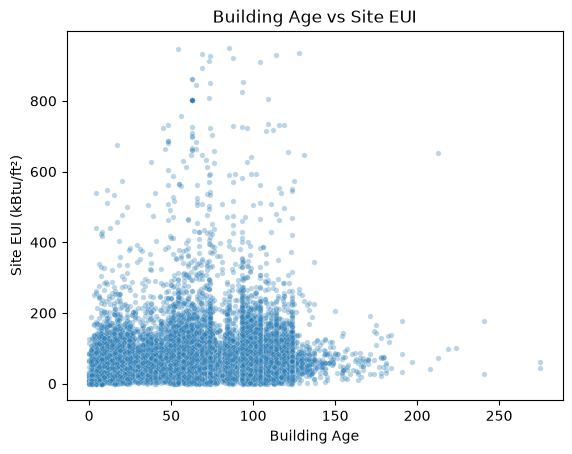

,Building Age,Site EUI (kBtu/ft²)
Building Age,1.000000,0.066717
Site EUI (kBtu/ft²),0.066717,1.000000


In [37]:
# Plot building age vs Site EUI
sns.scatterplot(
    x='Building Age',
    y='Site EUI (kBtu/ft²)',
    data=df_energy,
    alpha=0.3,
    s=15
)

plt.title('Building Age vs Site EUI')
plt.xlabel('Building Age')
plt.ylabel('Site EUI (kBtu/ft²)')
plt.show()

# Correlation between building age and Site EUI
df_energy[['Building Age', 'Site EUI (kBtu/ft²)']].corr()

### Insight: Building age also has little overall linear relationship with EUI

The correlation between Building Age and Site EUI is **0.067**, indicating only a very weak positive relationship overall.

Older buildings therefore do not automatically have high EUI, and newer buildings do not automatically have low EUI. Building use, systems, operations, renovations, and fuel mix may be more important than age by itself. The later peer-relative analysis provides a more useful way to evaluate whether age matters among comparable buildings.


### 3.4 Energy-Source Composition and EUI

`Percent Electricity` is restricted to the valid 0–100% range for this analysis. The relationship is interpreted as an association and may partly reflect differences in property type and end uses.

In [38]:
# Inspect Percent Electricity 
df_energy['Percent Electricity'].describe()

count    28647.000000
mean        39.119224
std         26.846192
min        -13.900000
25%         17.400000
50%         29.400000
75%         55.900000
max        100.000000
Name: Percent Electricity, dtype: float64

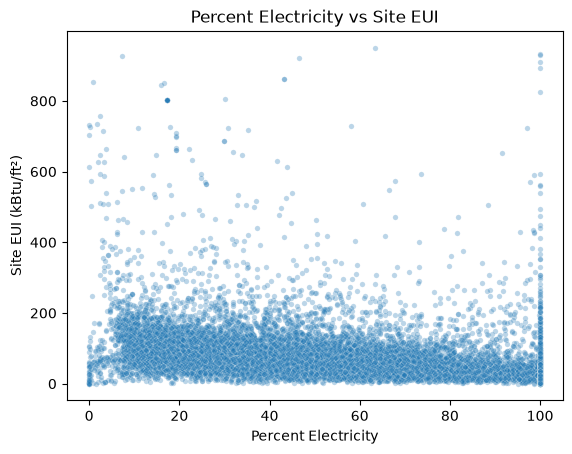

,Percent Electricity,Site EUI (kBtu/ft²)
Percent Electricity,1.000000,-0.264554
Site EUI (kBtu/ft²),-0.264554,1.000000


In [39]:
# Remove invalid negative/out-of-range values for this analysis
df_electricity = df_energy[df_energy['Percent Electricity'].between(0, 100)].copy()

# Plot Percent Electricity and GFA
sns.scatterplot(
    x='Percent Electricity',
    y='Site EUI (kBtu/ft²)',
    data=df_electricity,
    alpha=0.3,
    s=15
)

plt.title('Percent Electricity vs Site EUI')
plt.xlabel('Percent Electricity')
plt.ylabel('Site EUI (kBtu/ft²)')
plt.show()

# Correlation
df_electricity[['Percent Electricity', 'Site EUI (kBtu/ft²)']].corr()

In [40]:
# Group buildings into electricity-share bins and compare median Site EUI
df_electricity['Electricity Group'] = pd.cut(
    df_electricity['Percent Electricity'],
    bins=[0, 20, 40, 60, 80, 100],
    include_lowest=True
)

electricity_summary = (
    df_electricity.groupby('Electricity Group', observed=True)['Site EUI (kBtu/ft²)']
    .median()
)

electricity_summary

Electricity Group
(-0.001, 20.0]    82.7
(20.0, 40.0]      69.3
(40.0, 60.0]      62.2
(60.0, 80.0]      51.4
(80.0, 100.0]     30.7
Name: Site EUI (kBtu/ft²), dtype: float64

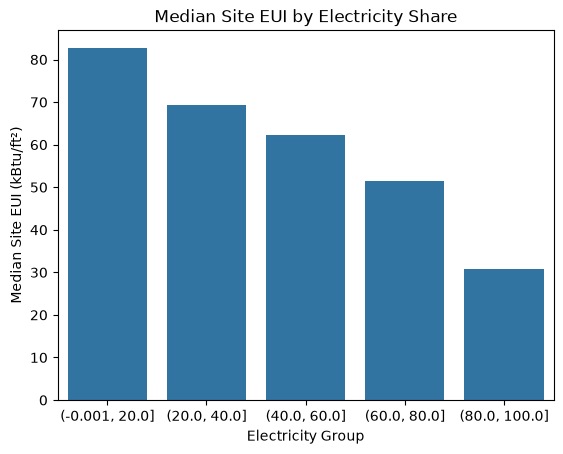

In [41]:
# Visualize median Site EUI by electricity-share group
sns.barplot(
    data=df_electricity,
    x='Electricity Group',
    y='Site EUI (kBtu/ft²)',
    errorbar=None,
    estimator=np.median
)

plt.title('Median Site EUI by Electricity Share')
plt.xlabel('Electricity Group')
plt.ylabel('Median Site EUI (kBtu/ft²)')
plt.show()

### Insight: Higher electricity share is associated with lower Site EUI

Percent Electricity has a **-0.265 correlation** with Site EUI, a modest negative association. The grouped medians show a clear pattern:

- 0–20% electricity: **82.7 kBtu/ft²**
- 20–40%: **69.3 kBtu/ft²**
- 40–60%: **62.2 kBtu/ft²**
- 60–80%: **51.4 kBtu/ft²**
- 80–100%: **30.7 kBtu/ft²**

This suggests that energy-source composition is associated with EUI. However, this should not be interpreted causally. Property type and end-use requirements likely influence both fuel mix and EUI.


## 4. Peer-Relative Energy Performance

Absolute EUI is strongly affected by building use, so this section compares each building with **buildings of the same original Portfolio Manager Property Type**.

Only property types with at least 30 buildings are used for peer analysis. Within each property type:
- lower EUI percentile = better relative energy performance;
- bottom 25% of EUI = **High Performer**;
- middle 50% = **Typical Performer**;
- top 25% of EUI = **Low Performer**.

In [42]:
# Use the original Portfolio Manager property type for peer comparisons
peer_type_col = 'Primary Property Type - Portfolio Manager-Calculated'

# Keep only property types with at least 30 buildings
peer_property_counts = df_energy[peer_type_col].value_counts()
comparable_properties = peer_property_counts[peer_property_counts >= 30].index

df_properties = df_energy[df_energy[peer_type_col].isin(comparable_properties)].copy()

# Rank each building's EUI within its own property type
# Lower EUI percentile = better energy performance relative to peers.
df_properties['EUI Peer Percentile'] = (
    df_properties.groupby(peer_type_col)['Site EUI (kBtu/ft²)']
    .rank(pct=True)
)

# Create three peer-performance groups
df_properties['Peer Performance'] = 'Typical Performer'
df_properties.loc[
    df_properties['EUI Peer Percentile'] <= 0.25,
    'Peer Performance'
] = 'High Performer'
df_properties.loc[
    df_properties['EUI Peer Percentile'] >= 0.75,
    'Peer Performance'
] = 'Low Performer'

df_properties['Peer Performance'].value_counts()

Peer Performance
Typical Performer    14456
Low Performer         7268
High Performer        7227
Name: count, dtype: int64

In [43]:
# Compare peer-performance groups on characteristics examined earlier (age, GFA, % electricity)
print('Median Building Age:')
print(df_properties.groupby('Peer Performance')['Building Age'].median().sort_values())

print('\nMedian GFA:')
print(df_properties.groupby('Peer Performance')['Property GFA - Self-Reported (ft²)'].median().sort_values())

print('\nMedian Percent Electricity:')
print(df_properties.groupby('Peer Performance')['Percent Electricity'].median().sort_values())

print('\nNon-missing Percent Electricity observations:')
print(df_properties.groupby('Peer Performance')['Percent Electricity'].count())

Median Building Age:
Peer Performance
High Performer       68.0
Typical Performer    84.0
Low Performer        93.0
Name: Building Age, dtype: float64

Median GFA:
Peer Performance
Low Performer        51280.5
High Performer       60123.0
Typical Performer    68051.5
Name: Property GFA - Self-Reported (ft²), dtype: float64

Median Percent Electricity:
Peer Performance
Low Performer        19.6
Typical Performer    24.7
High Performer       63.4
Name: Percent Electricity, dtype: float64

Non-missing Percent Electricity observations:
Peer Performance
High Performer        6800
Low Performer         7164
Typical Performer    14318
Name: Percent Electricity, dtype: int64


### Insight: Peer-relative comparisons reveal clearer differences

After comparing buildings only with others of the **same original Portfolio Manager Property Type**, the median characteristics are:

- **Building Age:** High - 68 years, Typical - 84 years, Low - 93 years
- **GFA:** High - 60,123 ft², Typical - 68,052 ft², Low - 51,281 ft²
- **Percent Electricity:** High - 63.4%, Typical - 24.7%, Low - 19.6%

Building size still shows no simple pattern. Age becomes more informative within peer groups: poorer performers are older on median. The strongest distinction is energy-source composition, with high performers having a much larger median electricity share.

This suggests that high- and low-EUI buildings differ on identifiable characteristics when compared within the same property type, and shows why peer-relative analysis is more informative than comparing all buildings together.

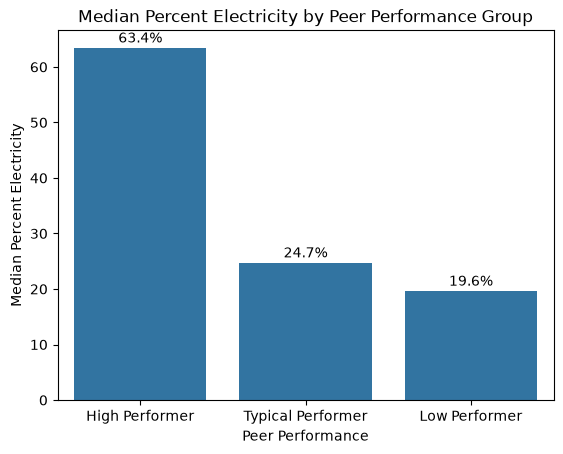

In [44]:
# Plot Peer Performance vs Percent Electricity
ax = sns.barplot(
    data=df_properties,
    x='Peer Performance',
    y='Percent Electricity',
    order=['High Performer', 'Typical Performer', 'Low Performer'],
    errorbar=None,
    estimator=np.median
)

plt.title('Median Percent Electricity by Peer Performance Group')
plt.xlabel('Peer Performance')
plt.ylabel('Median Percent Electricity')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.show()

### 4.1 Extreme Peer Performers

To make the contrast clearer, the next step focuses on the bottom 10% and top 10% of EUI **within each property type**.

In [45]:
# Identify extreme peer-relative performers
df_properties['Extreme Performance'] = 'Not Extreme'

df_properties.loc[
    df_properties['EUI Peer Percentile'] <= 0.10,
    'Extreme Performance'
] = 'Extremely High Performer'

df_properties.loc[
    df_properties['EUI Peer Percentile'] >= 0.90,
    'Extreme Performance'
] = 'Extremely Low Performer'

df_properties['Extreme Performance'].value_counts()

Extreme Performance
Not Extreme                 23158
Extremely Low Performer      2916
Extremely High Performer     2877
Name: count, dtype: int64

In [46]:
# Create a dataframe containing only the extreme groups
df_extreme = df_properties[
    df_properties['Extreme Performance'].isin([
        'Extremely High Performer',
        'Extremely Low Performer'
    ])
].copy()

print('Median Building Age:')
print(df_extreme.groupby('Extreme Performance')['Building Age'].median())

print('\nMedian GFA:')
print(df_extreme.groupby('Extreme Performance')['Property GFA - Self-Reported (ft²)'].median())

print('\nMedian Percent Electricity:')
print(df_extreme.groupby('Extreme Performance')['Percent Electricity'].median())

Median Building Age:
Extreme Performance
Extremely High Performer    74.0
Extremely Low Performer     92.0
Name: Building Age, dtype: float64

Median GFA:
Extreme Performance
Extremely High Performer    51609.0
Extremely Low Performer     48384.0
Name: Property GFA - Self-Reported (ft²), dtype: float64

Median Percent Electricity:
Extreme Performance
Extremely High Performer    82.8
Extremely Low Performer     19.7
Name: Percent Electricity, dtype: float64


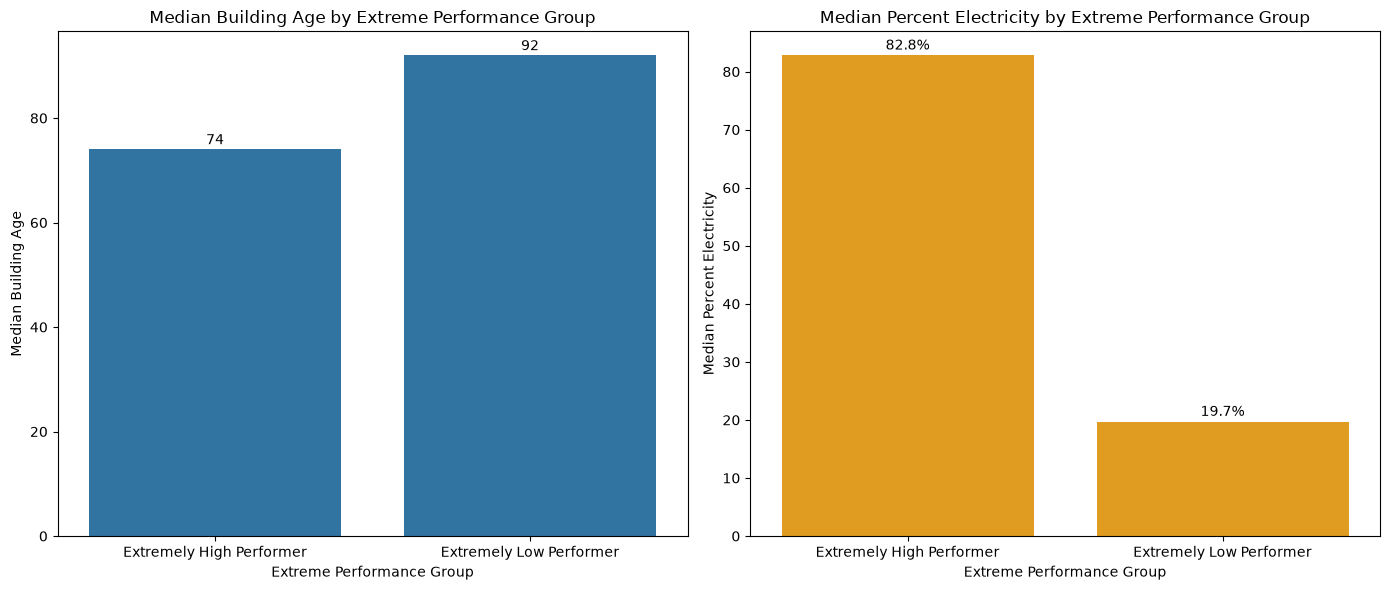

In [47]:
# Compare Building Age and Percent Electricity for extreme peer performers
fig, ax1 = plt.subplots(1, 2, figsize=(14, 6))

# Building Age
age = sns.barplot(
    data=df_extreme,
    x='Extreme Performance',
    y='Building Age',
    order=['Extremely High Performer', 'Extremely Low Performer'],
    estimator=np.median,
    errorbar=None,
    ax=ax1[0]
)
age.set_xlabel('Extreme Performance Group')
age.set_ylabel('Median Building Age')
age.set_title('Median Building Age by Extreme Performance Group')

for bar in age.patches:
    height = bar.get_height()
    age.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.0f}',
        ha='center'
    )

# Percent Electricity
electric = sns.barplot(
    data=df_extreme,
    x='Extreme Performance',
    y='Percent Electricity',
    order=['Extremely High Performer', 'Extremely Low Performer'],
    estimator=np.median,
    errorbar=None,
    ax=ax1[1],
    color='orange'
)
electric.set_xlabel('Extreme Performance Group')
electric.set_ylabel('Median Percent Electricity')
electric.set_title('Median Percent Electricity by Extreme Performance Group')

for bar in electric.patches:
    height = bar.get_height()
    electric.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Insight: The strongest contrast remains among the extreme peer groups

For the bottom and top 10% of EUI within each property type:

- **Median Building Age:** 74 years for Extremely High Performers vs. 92 for Extremely Low Performers
- **Median GFA:** 51,609 ft² for Exremely High Performers vs. 48,384 ft² for Extremely Low Performers
- **Median Percent Electricity:** 82.8% for Extremely High Performers vs. 19.7% for Extremely Low Performers

The GFA difference remains small, while age shows a moderate contrast and Percent Electricity shows a very large contrast. This reinforces the earlier finding that **energy-source composition is the clearest observed characteristic distinguishing the best and worst peer-relative energy performers**.


## 5. Water Use Intensity Analysis

Water analysis repeats the same broad descriptive questions using Water Use Intensity (WUI). The goal is to see whether the characteristics associated with energy performance also appear to explain water-use efficiency.

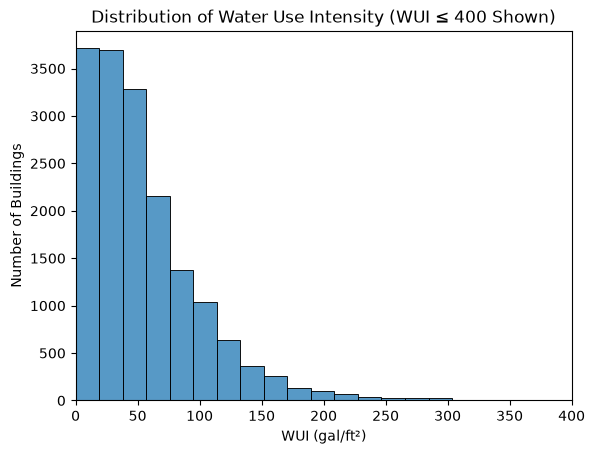

In [48]:
# Distribution of Water Use Intensity
sns.histplot(
    data=df_water,
    x='Water Use Intensity (WUI) (gal/ft²)',
    bins=50
)

plt.title('Distribution of Water Use Intensity (WUI ≤ 400 Shown)')
plt.xlabel('WUI (gal/ft²)')
plt.ylabel('Number of Buildings')
plt.xlim(0, 400)
plt.show()

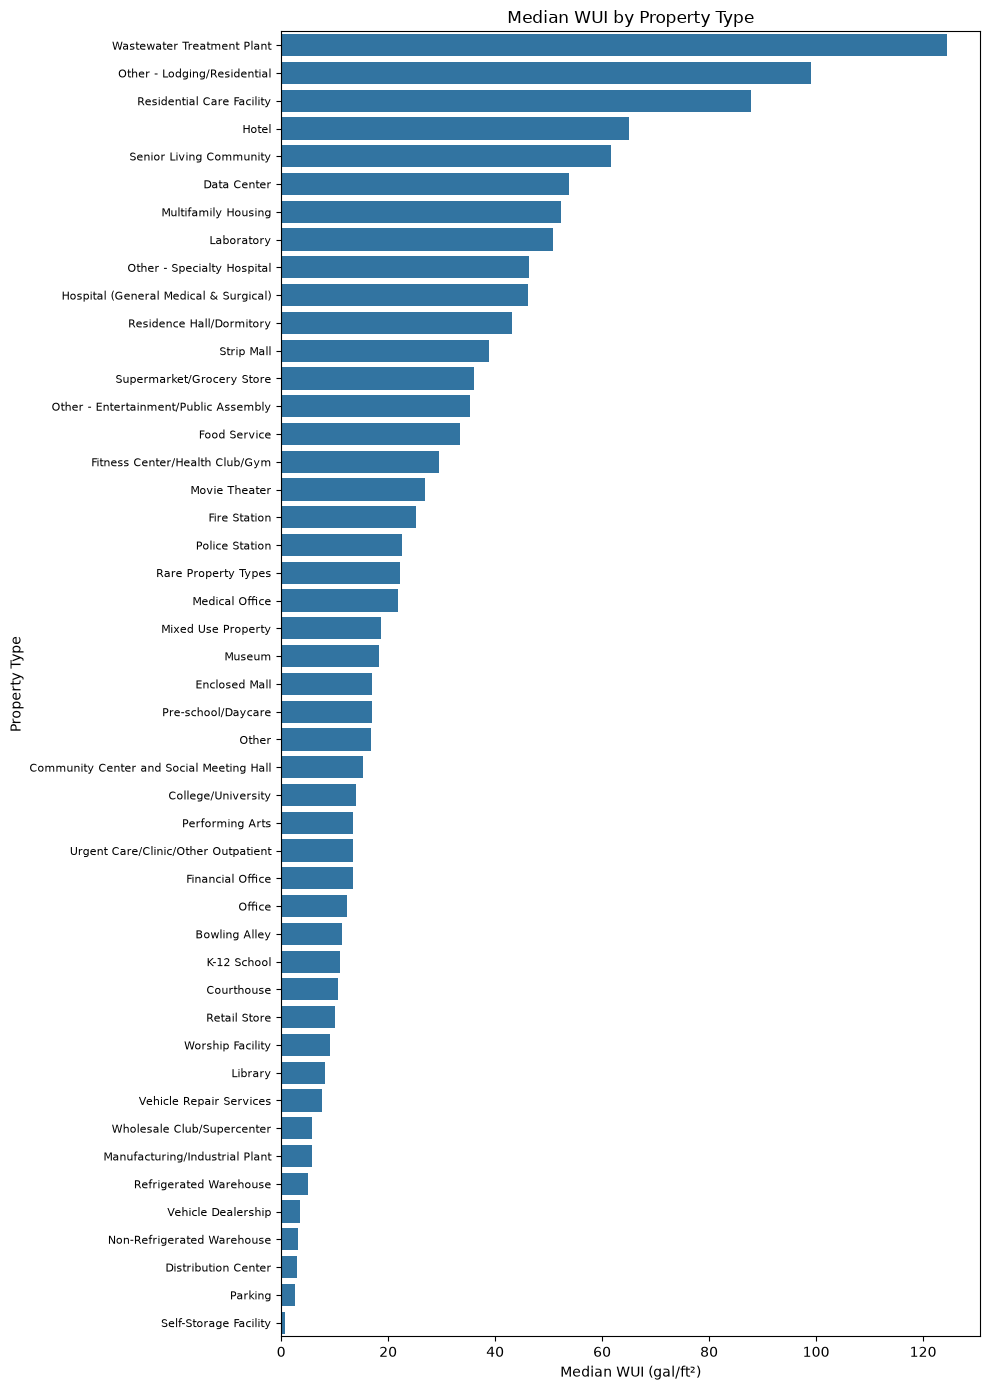

,count,median
Property Type Grouped,,
Wastewater Treatment Plant,11,124.416676
Other - Lodging/Residential,64,98.968152
Residential Care Facility,60,87.786114
Hotel,416,65.027530
Senior Living Community,115,61.679480
Data Center,59,53.758898
Multifamily Housing,12234,52.355694
Laboratory,16,50.799202
Other - Specialty Hospital,12,46.268324


In [49]:
# Call summary_by_property_type function to create new variable
wui_property_summary = summary_by_property_type(
    df_water,
    'Water Use Intensity (WUI) (gal/ft²)'
)

# Create new variable to define bar plot order
property_order_water = wui_property_summary.index

# Create bar plot
plt.figure(figsize=(10, 14))

sns.barplot(
    data=df_water,
    y='Property Type Grouped',
    x='Water Use Intensity (WUI) (gal/ft²)',
    order=property_order_water,
    estimator=np.median,
    errorbar=None
)

plt.title('Median WUI by Property Type')
plt.xlabel('Median WUI (gal/ft²)')
plt.ylabel('Property Type')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Display summary table
wui_property_summary

### Insight: Water-use patterns differ from energy-use patterns

Median WUI also varies substantially by property type, but the highest-water-use categories are especially concentrated in **occupant-intensive or residential uses**. The highest medians include **Wastewater Treatment Plant (124.4), Other — Lodging/Residential (99.0), Residential Care Facility (87.8), Hotel (65.0), and Senior Living Community (61.7).**

At the low end are **Self-Storage Facility (0.6), Parking (2.5), Distribution Center (2.9), Non-Refrigerated Warehouse (3.1), and Vehicle Dealership (3.5).**

This suggests a useful distinction: energy intensity appears strongly influenced by process and equipment requirements, while water intensity appears more closely tied to occupancy patterns and water-dependent activities such as bathing, toilets, laundry, kitchens, cleaning, and process water. These results suggest that energy and water have different drivers. 


### 5.1 Building Age and WUI

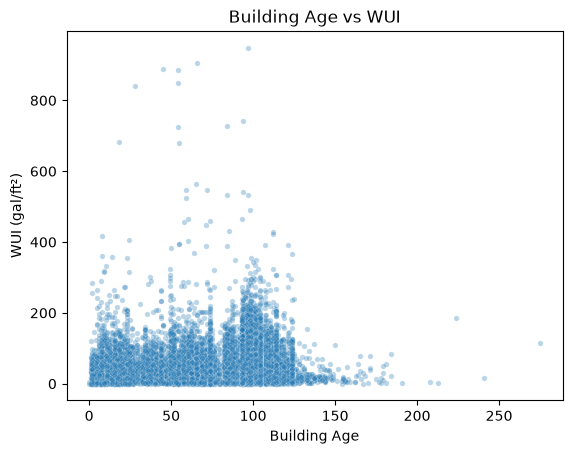

,Building Age,Water Use Intensity (WUI) (gal/ft²)
Building Age,1.000000,0.113432
Water Use Intensity (WUI) (gal/ft²),0.113432,1.000000


In [50]:
# Building Age vs WUI
sns.scatterplot(
    data=df_water,
    x='Building Age',
    y='Water Use Intensity (WUI) (gal/ft²)',
    s=15,
    alpha=0.3
)

plt.title('Building Age vs WUI')
plt.xlabel('Building Age')
plt.ylabel('WUI (gal/ft²)')
plt.show()

# Correlation
df_water[['Building Age', 'Water Use Intensity (WUI) (gal/ft²)']].corr()

### Insight: Building age has only a weak relationship with WUI

The correlation between Building Age and WUI is **0.113**, a weak positive relationship. Older buildings tend to have slightly higher WUI on average, but age explains little of the overall variation.


### 5.2 Building Size and WUI

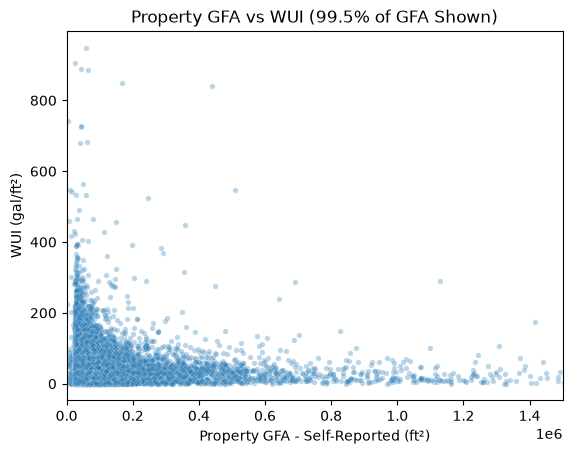

,Property GFA - Self-Reported (ft²),Water Use Intensity (WUI) (gal/ft²)
Property GFA - Self-Reported (ft²),1.000000,-0.132378
Water Use Intensity (WUI) (gal/ft²),-0.132378,1.000000


In [51]:
# Building Size vs WUI
sns.scatterplot(
    data=df_water,
    x='Property GFA - Self-Reported (ft²)',
    y='Water Use Intensity (WUI) (gal/ft²)',
    s=15,
    alpha=0.3
)

plt.title('Property GFA vs WUI (99.5% of GFA Shown)')
plt.xlabel('Property GFA - Self-Reported (ft²)')
plt.ylabel('WUI (gal/ft²)')
plt.xlim(0, 1500000)
plt.show()

# Correlation
df_water[[
    'Property GFA - Self-Reported (ft²)',
    'Water Use Intensity (WUI) (gal/ft²)'
]].corr()

### Insight: Larger buildings have slightly lower WUI, but the relationship is weak

The correlation between GFA and WUI is **-0.132**, a weak negative relationship. Smaller buildings show much greater variation in WUI, while larger buildings are more concentrated at lower intensities.

As with EUI, building size by itself is not a strong explanation of performance.


## 6. Energy and Water Performance Together

Before comparing energy and water, a sensitivity check compares Site EUI with Weather Normalized Site EUI. Because all buildings are being compared within the same city and calendar year, Site EUI is retained as the main metric if the two measures produce nearly identical relative patterns.

In [52]:
# Sensitivity check: Site EUI vs Weather Normalized Site EUI
df_eui_compare = df_energy.dropna(
    subset=[
        'Site EUI (kBtu/ft²)',
        'Weather Normalized Site EUI (kBtu/ft²)'
    ]
).copy()

df_eui_compare[[
    'Site EUI (kBtu/ft²)',
    'Weather Normalized Site EUI (kBtu/ft²)'
]].corr()

,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²)
Site EUI (kBtu/ft²),1.000000,0.999173
Weather Normalized Site EUI (kBtu/ft²),0.999173,1.000000


### Insight: Site EUI and Weather Normalized Site EUI produce nearly identical relative patterns

The correlation between Site EUI and Weather Normalized Site EUI is **0.9992**. Because this analysis compares buildings within the same city and calendar year, weather normalization does not materially change the relative pattern of energy performance.

Site EUI is therefore retained as the primary metric, with Weather Normalized Site EUI serving as a sensitivity check.


In [53]:
# Merge energy and water records for properties with usable values in both datasets
df_energy_water = df_energy.merge(
    df_water[['Property ID', 'Water Use Intensity (WUI) (gal/ft²)']],
    on='Property ID',
    how='inner'
)

print('Merged energy-water shape:', df_energy_water.shape)
df_energy_water.describe()

Merged energy-water shape: (16450, 25)


,Calendar Year,Property ID,Longitude,Latitude,Year Built,Number of Buildings,Occupancy,Property GFA - Self-Reported (ft²),Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Percent Electricity,Natural Gas Use (kBtu),Electricity Use - Grid Purchase (kBtu),Fuel Oil #2 Use (kBtu),District Steam Use (kBtu),Water Use (All Water Sources) (kgal),Building Age,Water Use Intensity (WUI) (gal/ft²)
count,16450.0,1.645000e+04,16000.000000,16000.000000,16450.000000,16450.000000,16450.000000,1.645000e+04,16450.000000,15725.000000,16403.000000,1.562800e+04,1.640600e+04,2.492000e+03,7.960000e+02,16450.000000,16450.000000,16450.000000
mean,2024.0,1.584199e+07,-73.937244,40.749139,1951.684863,1.291550,97.751368,1.133517e+05,75.662790,77.725119,37.728763,4.731863e+06,3.365955e+06,2.460872e+06,1.206698e+07,4864.324486,72.315137,55.194302
std,0.0,1.613036e+07,0.060987,0.077011,35.635743,3.655093,8.229389,1.993957e+05,48.162159,49.207402,26.136943,2.292250e+07,1.082943e+07,3.748853e+06,1.868360e+07,8494.901184,35.635743,51.059807
min,2024.0,8.604000e+03,-74.243582,40.516065,1749.000000,1.000000,5.000000,6.000000e+02,0.000000,0.000000,-13.900000,0.000000e+00,-1.632574e+06,0.000000e+00,-7.759206e+07,1.000000,0.000000,0.003701
25%,2024.0,4.934199e+06,-73.979106,40.702480,1926.000000,1.000000,100.000000,3.896400e+04,52.225000,53.700000,16.800000,7.496832e+05,6.238976e+05,1.656000e+05,2.057504e+06,1363.850000,48.000000,22.152933
50%,2024.0,6.794255e+06,-73.949421,40.750747,1939.000000,1.000000,100.000000,6.000000e+04,70.500000,72.700000,27.900000,2.537454e+06,1.082263e+06,1.677576e+06,5.732626e+06,3005.700000,85.000000,43.624495
75%,2024.0,2.135550e+07,-73.904186,40.808379,1976.000000,1.000000,100.000000,1.088968e+05,89.700000,92.400000,54.400000,4.607445e+06,2.451918e+06,3.278804e+06,1.376897e+07,5612.900000,98.000000,74.298535
max,2024.0,6.612869e+07,-73.702913,40.912869,2024.000000,179.000000,100.000000,5.970773e+06,950.600000,968.500000,100.000000,1.586253e+09,4.872751e+08,5.568376e+07,2.006160e+08,328147.100000,275.000000,948.745364


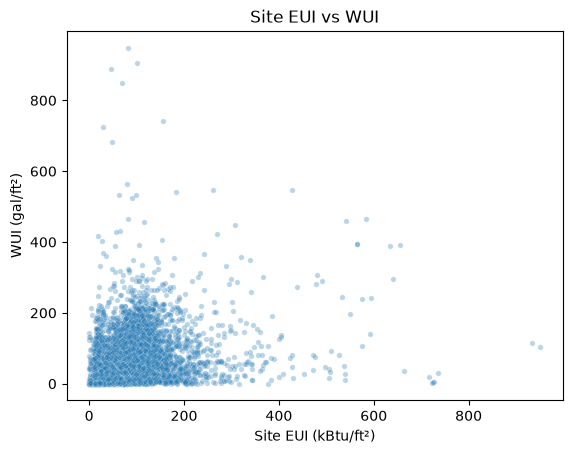

,Site EUI (kBtu/ft²),Water Use Intensity (WUI) (gal/ft²)
Site EUI (kBtu/ft²),1.00000,0.32036
Water Use Intensity (WUI) (gal/ft²),0.32036,1.00000


In [54]:
# Site EUI vs WUI
sns.scatterplot(
    data=df_energy_water,
    x='Site EUI (kBtu/ft²)',
    y='Water Use Intensity (WUI) (gal/ft²)',
    s=15,
    alpha=0.3
)

plt.title('Site EUI vs WUI')
plt.xlabel('Site EUI (kBtu/ft²)')
plt.ylabel('WUI (gal/ft²)')
plt.show()

# Overall correlation between EUI and WUI
df_energy_water[[
    'Site EUI (kBtu/ft²)',
    'Water Use Intensity (WUI) (gal/ft²)'
]].corr()

### Insight: Energy and water performance are related, but not interchangeable

Among the **16,450 properties** with usable values for both metrics, Site EUI and WUI have a correlation of **0.320**. This is a modest positive association: buildings with higher energy intensity tend, on average, to have higher water intensity, but the relationship is far from one-to-one.

Energy and water performance share some common influences, but they also appear to have different drivers. The next peer-relative analysis will test whether a building that performs well on energy **relative to similar buildings** also tends to perform well on water relative to similar buildings.


### 6.1 Energy and Water Peer-Relative Analysis

In [55]:
# Count buildings in each property type in the combined energy + water dataset
energy_water_counts = df_energy_water[ 'Primary Property Type - Portfolio Manager-Calculated'].value_counts()

# Keep property types with at least 30 buildings
usable_property_types = energy_water_counts[
    energy_water_counts >= 30 
    ].index

# Create a dataframe containing only those property types
df_energy_water_peers = df_energy_water[
    df_energy_water['Primary Property Type - Portfolio Manager-Calculated'].isin(usable_property_types)
    ].copy()

print(df_energy_water_peers.shape)
print(len(usable_property_types))

(16085, 25)
28


In [56]:
# Rank EUI within each property type
df_energy_water_peers['EUI Peer Percentile'] = (
    df_energy_water_peers.groupby('Primary Property Type - Portfolio Manager-Calculated')['Site EUI (kBtu/ft²)'].rank(pct=True)
)

# Rank WUI within each property type
df_energy_water_peers['WUI Peer Percentile'] = (
    df_energy_water_peers.groupby('Primary Property Type - Portfolio Manager-Calculated')['Water Use Intensity (WUI) (gal/ft²)'].rank(pct=True)
)

# Calculate EUI + WUI Correlation
df_energy_water_peers[['EUI Peer Percentile', 'WUI Peer Percentile']].corr()

,EUI Peer Percentile,WUI Peer Percentile
EUI Peer Percentile,1.000000,0.415743
WUI Peer Percentile,0.415743,1.000000


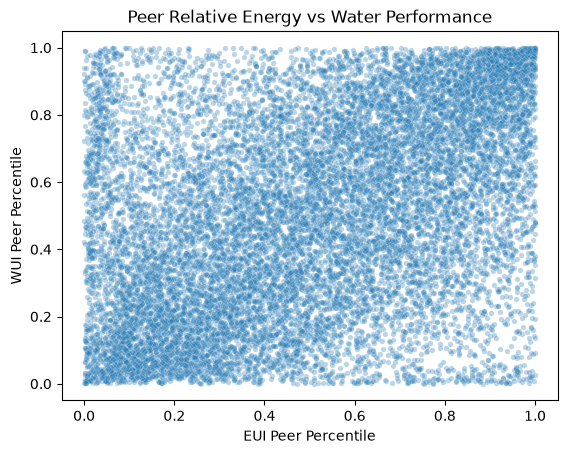

In [57]:
# Make Peer Relative EUI vs WUI Scatterplot

sns.scatterplot(
    data=df_energy_water_peers,
    x='EUI Peer Percentile',
    y='WUI Peer Percentile',
    alpha=0.3, 
    s=15
)

plt.title('Peer Relative Energy vs Water Performance')
plt.xlabel('EUI Peer Percentile')
plt.ylabel('WUI Peer Percentile')

plt.show()

### Insight: Buildings that perform relatively well on energy often perofrm relatively well on water, but relationship is not 1:1

Buildings that perform relatively well on energy compared with buildings of the same property type also tend to perform relatively well on water, and buildings that perform poorly on energy tend to perform poorly on water. However, the relationship is only **moderate (0.42)**, meaning energy and water performance are related but still have important independent drivers.

There is visible tendency for points to concentrate toward the bottom left and top right of the scatterplot.


In [58]:
# Identify Energy and Water performance crossover

# Create Energy and Water Performance column, and fill with a string
df_energy_water_peers['Energy and Water Performance'] = 'Unassigned'

# Create Groups and update Energy and Water Performance column
df_energy_water_peers.loc[
    (df_energy_water_peers['EUI Peer Percentile'] <= 0.5) &
     (df_energy_water_peers['WUI Peer Percentile'] <= 0.5),
    'Energy and Water Performance'
    ] = 'Better on Both'

df_energy_water_peers.loc[
    (df_energy_water_peers['EUI Peer Percentile'] <= 0.5) &
    (df_energy_water_peers['WUI Peer Percentile'] > 0.5),
    'Energy and Water Performance'
    ] = 'Better Energy / Worse Water'

df_energy_water_peers.loc[
    (df_energy_water_peers['EUI Peer Percentile'] > 0.5) &
    (df_energy_water_peers['WUI Peer Percentile'] <= 0.5),
    'Energy and Water Performance'
    ] = 'Worse Energy / Better Water'

df_energy_water_peers.loc[
    (df_energy_water_peers['EUI Peer Percentile'] > 0.5) & 
    (df_energy_water_peers['WUI Peer Percentile'] > 0.5),
    'Energy and Water Performance'
    ] = 'Worse on Both'

print(df_energy_water_peers['Energy and Water Performance'].value_counts())
print(df_energy_water_peers['Energy and Water Performance'].value_counts(normalize=True) * 100)

Energy and Water Performance
Worse on Both                  5356
Better on Both                 5347
Better Energy / Worse Water    2692
Worse Energy / Better Water    2690
Name: count, dtype: int64
Energy and Water Performance
Worse on Both                  33.298104
Better on Both                 33.242151
Better Energy / Worse Water    16.736090
Worse Energy / Better Water    16.723656
Name: proportion, dtype: float64


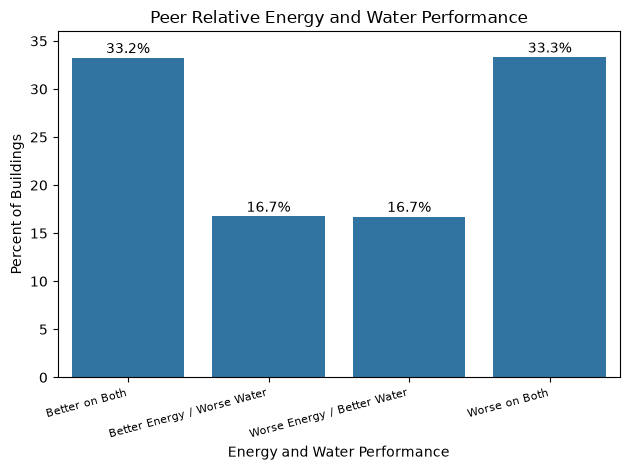

In [59]:
# Create a bar chart demonstrating the performance groups by percent

# Save percentage calculation to a variable
energy_water_pct = df_energy_water_peers['Energy and Water Performance'].value_counts(normalize=True) * 100

# Create Bar plot
ax = sns.barplot(
    x=energy_water_pct.index,
    y=energy_water_pct.values,
    order=['Better on Both', 'Better Energy / Worse Water', 'Worse Energy / Better Water', 'Worse on Both']
)

plt.title('Peer Relative Energy and Water Performance')
plt.ylabel('Percent of Buildings')
plt.xticks(rotation=15, ha='right', fontsize=8)

plt.ylim(0, 36)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Insight: Energy and water performance are meaningfully related within comparable buildings

About two-thirds of buildings fall on the same side of their peer-group median for both resources. However, roughly one-third perform well on one resource and poorly on the other, suggesting that energy and water efficiency also have distinct drivers.

In [62]:
# Create a combined peer-performance measure
df_energy_water_peers['Combined Peer Percentile'] = (
    df_energy_water_peers['EUI Peer Percentile'] + df_energy_water_peers['WUI Peer Percentile']) / 2

# Define candidates for immediate investigation based on performance
priority_candidates_worse = df_energy_water_peers[
    df_energy_water_peers['Energy and Water Performance'] == 'Worse on Both'
    ].copy()

# Rank the buildings
priority_candidates_worse = priority_candidates_worse.sort_values(
    'Combined Peer Percentile', 
    ascending=False
)

# Display top 10 buildings worth investigating for efficiency upgrades
priority_candidates_worse[[
    'Property ID', 
    'Primary Property Type - Portfolio Manager-Calculated',
    'Borough',
    'Site EUI (kBtu/ft²)',
    'Water Use Intensity (WUI) (gal/ft²)',
    'EUI Peer Percentile',
    'WUI Peer Percentile',
    'Combined Peer Percentile'
]].head(10)

,Property ID,Primary Property Type - Portfolio Manager-Calculated,Borough,Site EUI (kBtu/ft²),Water Use Intensity (WUI) (gal/ft²),EUI Peer Percentile,WUI Peer Percentile,Combined Peer Percentile
5395,6266163,Retail Store,QUEENS,478.3,282.233207,1.000000,1.000000,1.000000
10647,15335891,Refrigerated Warehouse,QUEENS,228.0,95.949434,1.000000,1.000000,1.000000
6944,6621646,Multifamily Housing,STATEN IS,541.2,460.223881,0.999662,0.999409,0.999536
16240,60266693,Multifamily Housing,MANHATTAN,633.5,387.840909,0.999916,0.998819,0.999367
8617,6821188,Multifamily Housing,BROOKLYN,338.9,348.868394,0.998397,0.998228,0.998312
11425,20023406,Multifamily Housing,BRONX,269.9,421.393189,0.996962,0.999156,0.998059
616,2665405,Multifamily Housing,MANHATTAN,491.8,288.912686,0.999072,0.996287,0.997679
14356,33955828,Hotel,MANHATTAN,321.1,358.762140,0.997549,0.997549,0.997549
9978,11534266,Multifamily Housing,BRONX,299.4,296.674458,0.997722,0.997046,0.997384
10786,15584283,Multifamily Housing,MANHATTAN,241.5,365.094340,0.996203,0.998565,0.997384


### Note ###

These properties represent some high-priority candidates for further investigation, because they rank poorly on both energy and water performance compared with buildings of the same property type. 

In [63]:
# Define candidates for immediate investigation based on performance
priority_candidates_better = df_energy_water_peers[
    df_energy_water_peers['Energy and Water Performance'] == 'Better on Both'
    ].copy()

# Rank the buildings
priority_candidates_better = priority_candidates_better.sort_values(
    'Combined Peer Percentile', 
    ascending=False
)

# Display top 10 buildings worth benchmarking from
priority_candidates_better[[
    'Property ID', 
    'Primary Property Type - Portfolio Manager-Calculated',
    'Borough',
    'Site EUI (kBtu/ft²)',
    'Water Use Intensity (WUI) (gal/ft²)',
    'EUI Peer Percentile',
    'WUI Peer Percentile',
    'Combined Peer Percentile'
]].head(10)

,Property ID,Primary Property Type - Portfolio Manager-Calculated,Borough,Site EUI (kBtu/ft²),Water Use Intensity (WUI) (gal/ft²),EUI Peer Percentile,WUI Peer Percentile,Combined Peer Percentile
12111,21355005,K-12 School,BRONX,56.4,10.973601,0.500000,0.496667,0.498333
15013,49662192,Manufacturing/Industrial Plant,QUEENS,51.3,5.646437,0.495192,0.500000,0.497596
2349,3121003,Multifamily Housing,QUEENS,71.3,51.759453,0.484557,0.498397,0.491477
7109,6664223,Multifamily Housing,BRONX,71.6,51.110054,0.489367,0.492152,0.490759
3422,4403094,Multifamily Housing,BROOKLYN,71.3,51.542188,0.484557,0.496456,0.490506
4384,5053051,Multifamily Housing,QUEENS,71.3,51.416874,0.484557,0.495612,0.490084
1642,2806009,Multifamily Housing,MANHATTAN,71.8,50.521404,0.493460,0.483122,0.488291
2672,3525575,Office,MANHATTAN,57.2,11.985088,0.482504,0.492224,0.487364
8624,6821269,Multifamily Housing,BROOKLYN,71.6,50.642857,0.489367,0.484979,0.487173
4612,5849966,Multifamily Housing,MANHATTAN,71.4,50.836184,0.485992,0.488186,0.487089


### Note ###

These properties represent some top candidates for benchmarking, as they rank highly in both water and energy performance compared wtih buildings of the same property type. 

## Overall Findings and Recommendations

This analysis found that **proerty type is a major source of variation in both energy and water intensity,** reinforcing the importance of comparing buildings with similar uses rather than relying on aboslute EUI or WUI alone. 

Building size and age showed only weak overall relationships with EUI, while **electricity share** showed a clearer **negative association with EUI.** Peer-relative analysis reinforced this pattern: electricicy share most clearly disinguishes better- and worse- performing buildings, while building size provided relatively little separation. 

Energy and water performance were moderately related after accounting for property type. Approximately **66.5%** of buildings performed **on the same side of their peer median for both resources**, while roughly one third performed better on one resource and worse on the other. 

These findings support a peer-based framework for efficiency targeting. 
- Buildings performing poorly on both energy and water relative to comparable properties may be stronger candidates for comprehensive efficiency investigation. **A list of the top 10 properties in this group has been provided for immediate action.**
- Buildings performing poorly on only one resource may warranted more targeted energy- or water-specific investigation.
- Buildings performing well on both may represent lower immediate priorities or useful peer benchmarks. **A list of the top 10 performers has been provided for benchmarking.**

These results identify candidates for futher investigation rather than diagnosing the cause of poor performance or prescribing specific efficiency measures. 